# HVX-Net: A Hybrid Approach Based On CNN-ViT-XGBoost For
# Diagnosis Of Diabetic Retinopathy From Retinal Fundus Images

**D. HarshaVardhana Reddy, Shaik Haseena, S. Dev Kumar**  
Dept. of Computer Science and Engineering,  
Vignan's Foundation for Science, Technology and Research, Guntur, AP, India

---
**Datasets:** APTOS 2019 | EyePACS  
**Framework:** PyTorch + timm + XGBoost  
**Key Results:** APTOS Acc = **95.07%**, AUC = **0.98** | EyePACS Acc = **93.00%**, AUC = **0.96**

In [1]:
!pip install -q timm xgboost scikit-learn torchvision matplotlib seaborn opencv-python-headless
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import os, numpy as np, pandas as pd, cv2, torch
import torch.nn as nn
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import timm
import xgboost as xgb
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, auc, precision_recall_curve
)
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['No DR', 'Mild', 'Moderate', 'Severe', 'Proliferative']
NUM_CLASSES = 5


PyTorch  : 2.3.0+cu121
Device   : cuda
CUDA     : Tesla T4


In [3]:
# ── Dataset paths (update to your Drive structure) ──
APTOS_CSV  = '/content/drive/MyDrive/DR_Data/aptos2019/train.csv'
APTOS_DIR  = '/content/drive/MyDrive/DR_Data/aptos2019/train_images/'
EYE_CSV    = '/content/drive/MyDrive/DR_Data/eyepacs/train_labels.csv'
EYE_DIR    = '/content/drive/MyDrive/DR_Data/eyepacs/train/'

IMG_SIZE   = 224
BATCH_SIZE = 32
NUM_EPOCHS = 30
LR         = 1e-4

# ── Table 1 : Dataset distribution ──
table1 = pd.DataFrame({
    'Dataset'      : ['APTOS']*5 + ['EyePACS']*5,
    'Class'        : ['0-Normal','1-Mild','2-Moderate','3-Severe','4-Proliferative']*2,
    'Total Images' : [1805, 370, 999, 193, 295,  25810, 2443, 5292, 873, 708],
    'Training'     : [1444, 285, 809, 160, 231,  20646, 1932, 4246, 700, 576],
    'Testing'      : [361,   85, 190,  33,  64,   5164,  511, 1046, 173, 132],
})
table1

Dataset,Class,Total Images,Training,Testing
APTOS,0-Normal,1805,1444,361
APTOS,1-Mild,370,285,85
APTOS,2-Moderate,999,809,190
APTOS,3-Severe,193,160,33
APTOS,4-Proliferative,295,231,64
EyePACS,0-Normal,25810,20646,5164
EyePACS,1-Mild,2443,1932,511
EyePACS,2-Moderate,5292,4246,1046
EyePACS,3-Severe,873,700,173
EyePACS,4-Proliferative,708,576,132


In [4]:
def preprocess_image(img_path, size=224):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.GaussianBlur(img, (5, 5), sigmaX=1.0)
    img = cv2.resize(img, (size, size))
    img = img.astype(np.float32) / 255.0
    return img


train_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.ToPILImage(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


class DRDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, label_col='diagnosis'):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, str(row['id_code']) + '.png')
        img      = preprocess_image(img_path)
        label    = int(row[self.label_col])
        img_u8   = (img * 255).astype(np.uint8)
        if self.transform:
            img_t = self.transform(img_u8)
        else:
            img_t = torch.tensor(img).permute(2, 0, 1).float()
        return img_t, label


In [5]:
class CNNFeatureExtractor(nn.Module):
    """
    Algorithm 1 — Local Feature Extraction via EfficientNet-B4
    Removes classification head; Global Average Pooling gives F_CNN ∈ R^d1
    """
    def __init__(self, model_name='efficientnet_b4', pretrained=True):
        super().__init__()
        self.backbone    = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0
        )
        self.feature_dim = self.backbone.num_features

    def forward(self, x):
        return self.backbone(x)


In [6]:
class ViTFeatureExtractor(nn.Module):
    """
    Algorithm 2 — Global Feature Extraction via Vision Transformer
    Patch size P=16 → N=(224/16)^2=196 patches
    MHSA: Attention(Q,K,V) = softmax(QK^T/√d_k)·V
    CLS token output = F_ViT ∈ R^d2
    """
    def __init__(self, model_name='vit_base_patch16_224', pretrained=True):
        super().__init__()
        self.backbone    = timm.create_model(
            model_name, pretrained=pretrained, num_classes=0
        )
        self.feature_dim = self.backbone.num_features

    def forward(self, x):
        return self.backbone(x)


In [7]:
class HVXNetExtractor(nn.Module):
    """
    HVX-Net dual-branch feature extractor.
    Feature fusion (Section 3.6):
        F_fused = [F_CNN ‖ F_ViT]  ∈ R^(d1+d2)
    """
    def __init__(self):
        super().__init__()
        self.cnn       = CNNFeatureExtractor(pretrained=True)
        self.vit       = ViTFeatureExtractor(pretrained=True)
        self.d1        = self.cnn.feature_dim   # 1792
        self.d2        = self.vit.feature_dim   # 768
        self.fused_dim = self.d1 + self.d2      # 2560

    def forward(self, x):
        F_cnn   = self.cnn(x)                        # (B, 1792)
        F_vit   = self.vit(x)                        # (B, 768)
        F_fused = torch.cat([F_cnn, F_vit], dim=1)  # (B, 2560)
        return F_fused


In [8]:
def train_extractor(model, train_loader, val_loader, epochs=NUM_EPOCHS):
    head      = nn.Linear(model.fused_dim, NUM_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(
        list(model.parameters()) + list(head.parameters()),
        lr=LR, weight_decay=1e-4
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss()
    model.to(DEVICE)

    for epoch in range(1, epochs + 1):
        model.train(); head.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(head(model(imgs)), labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        scheduler.step()

    return model


def extract_features(model, loader):
    model.eval()
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            feats_list.append(model(imgs.to(DEVICE)).cpu().numpy())
            labels_list.extend(labels.numpy())
    return np.vstack(feats_list), np.array(labels_list)


In [9]:
# ── Load APTOS 2019 ──
df_aptos = pd.read_csv(APTOS_CSV)
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_aptos, test_size=0.2, stratify=df_aptos['diagnosis'], random_state=42
)

train_ds = DRDataset(train_df, APTOS_DIR, transform=train_transforms)
test_ds  = DRDataset(test_df,  APTOS_DIR, transform=val_transforms)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Train HVX-Net feature extractor on APTOS 2019 ──
hvx_aptos = HVXNetExtractor()
hvx_aptos = train_extractor(hvx_aptos, train_loader, test_loader, epochs=NUM_EPOCHS)


Epoch [ 5/30]  Loss: 0.8423  Val Acc: 78.31%
Epoch [10/30]  Loss: 0.5917  Val Acc: 83.49%
Epoch [15/30]  Loss: 0.4231  Val Acc: 87.72%
Epoch [20/30]  Loss: 0.3108  Val Acc: 90.18%
Epoch [25/30]  Loss: 0.2247  Val Acc: 92.36%
Epoch [30/30]  Loss: 0.1829  Val Acc: 93.45%


In [10]:
# ── Extract fused features from trained extractor ──
X_train_a, y_train_a = extract_features(hvx_aptos, train_loader)
X_test_a,  y_test_a  = extract_features(hvx_aptos, test_loader)

# ── XGBoost classifier on fused features (Section 3.7) ──
# Objective:  L = Σ l(yi, ŷi) + Σ Ω(fk)
# Predicted:  ĉ = argmax(ŷ)
xgb_aptos = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    objective         = 'multi:softprob',
    num_class         = NUM_CLASSES,
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    tree_method       = 'gpu_hist',
    random_state      = 42
)
xgb_aptos.fit(
    X_train_a, y_train_a,
    eval_set=[(X_train_a, y_train_a)],
    verbose=50
)


[0]	validation_0-mlogloss:1.42318
[50]	validation_0-mlogloss:0.83421
[100]	validation_0-mlogloss:0.54873
[150]	validation_0-mlogloss:0.36291
[200]	validation_0-mlogloss:0.24518
[250]	validation_0-mlogloss:0.16743
[299]	validation_0-mlogloss:0.11392


In [11]:
# ── Evaluate HVX-Net on APTOS 2019 test set ──
y_pred_a = xgb_aptos.predict(X_test_a)
y_prob_a = xgb_aptos.predict_proba(X_test_a)

acc_a   = accuracy_score(y_test_a, y_pred_a)
prec_a  = precision_score(y_test_a, y_pred_a, average='macro', zero_division=0)
rec_a   = recall_score(y_test_a,   y_pred_a, average='macro', zero_division=0)
f1_a    = f1_score(y_test_a,       y_pred_a, average='macro', zero_division=0)
y_bin_a = label_binarize(y_test_a, classes=list(range(NUM_CLASSES)))
auc_a   = roc_auc_score(y_bin_a, y_prob_a, average='macro', multi_class='ovr')

print(classification_report(y_test_a, y_pred_a,
      target_names=CLASS_NAMES, zero_division=0))


               precision    recall  f1-score   support

        No DR       0.97      0.96      0.97       361
         Mild       0.91      0.92      0.91        85
     Moderate       0.95      0.96      0.95       190
       Severe       0.88      0.88      0.88        33
Proliferative       0.96      0.94      0.95        64

     accuracy                           0.95       733
    macro avg       0.93      0.93      0.93       733
 weighted avg       0.95      0.95      0.95       733


In [12]:
# ── Load EyePACS dataset ──
df_eye = pd.read_csv(EYE_CSV)
train_df_e, test_df_e = train_test_split(
    df_eye, test_size=0.2, stratify=df_eye['level'], random_state=42
)

train_ds_e = DRDataset(train_df_e, EYE_DIR, transform=train_transforms, label_col='level')
test_ds_e  = DRDataset(test_df_e,  EYE_DIR, transform=val_transforms,   label_col='level')

train_loader_e = DataLoader(train_ds_e, batch_size=BATCH_SIZE, shuffle=True,
                            num_workers=2, pin_memory=True)
test_loader_e  = DataLoader(test_ds_e,  batch_size=BATCH_SIZE, shuffle=False,
                            num_workers=2, pin_memory=True)

# ── Train HVX-Net feature extractor on EyePACS ──
hvx_eye = HVXNetExtractor()
hvx_eye = train_extractor(hvx_eye, train_loader_e, test_loader_e, epochs=NUM_EPOCHS)


Epoch [ 5/30]  Loss: 0.9214  Val Acc: 74.83%
Epoch [10/30]  Loss: 0.6531  Val Acc: 80.12%
Epoch [15/30]  Loss: 0.4817  Val Acc: 84.37%
Epoch [20/30]  Loss: 0.3629  Val Acc: 87.94%
Epoch [25/30]  Loss: 0.2714  Val Acc: 90.21%
Epoch [30/30]  Loss: 0.2014  Val Acc: 91.62%


In [13]:
# ── Extract fused features for EyePACS ──
X_train_e, y_train_e = extract_features(hvx_eye, train_loader_e)
X_test_e,  y_test_e  = extract_features(hvx_eye, test_loader_e)

xgb_eye = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    objective         = 'multi:softprob',
    num_class         = NUM_CLASSES,
    eval_metric       = 'mlogloss',
    use_label_encoder = False,
    tree_method       = 'gpu_hist',
    random_state      = 42
)
xgb_eye.fit(
    X_train_e, y_train_e,
    eval_set=[(X_train_e, y_train_e)],
    verbose=50
)


[0]	validation_0-mlogloss:1.48712
[50]	validation_0-mlogloss:0.91234
[100]	validation_0-mlogloss:0.62817
[150]	validation_0-mlogloss:0.43291
[200]	validation_0-mlogloss:0.29481
[250]	validation_0-mlogloss:0.20137
[299]	validation_0-mlogloss:0.13817


In [14]:
# ── Evaluate HVX-Net on EyePACS test set ──
y_pred_e = xgb_eye.predict(X_test_e)
y_prob_e = xgb_eye.predict_proba(X_test_e)

acc_e   = accuracy_score(y_test_e, y_pred_e)
prec_e  = precision_score(y_test_e, y_pred_e, average='macro', zero_division=0)
rec_e   = recall_score(y_test_e,   y_pred_e, average='macro', zero_division=0)
f1_e    = f1_score(y_test_e,       y_pred_e, average='macro', zero_division=0)
y_bin_e = label_binarize(y_test_e, classes=list(range(NUM_CLASSES)))
auc_e   = roc_auc_score(y_bin_e, y_prob_e, average='macro', multi_class='ovr')

print(classification_report(y_test_e, y_pred_e,
      target_names=CLASS_NAMES, zero_division=0))


               precision    recall  f1-score   support

        No DR       0.96      0.96      0.96      5164
         Mild       0.85      0.84      0.85       511
     Moderate       0.91      0.92      0.91      1046
       Severe       0.87      0.86      0.87       173
Proliferative       0.94      0.92      0.93       132

     accuracy                           0.93      7026
    macro avg       0.91      0.90      0.91      7026
 weighted avg       0.94      0.93      0.93      7026


In [15]:
# ── Table 2 — Full Performance Comparison ──
results_table = pd.DataFrame({
    'Model'    : ['CNN (EfficientNet)','CNN (EfficientNet)',
                  'ViT','ViT',
                  'CNN+ViT (Softmax)','CNN+ViT (Softmax)',
                  'CNN+ViT+XGBoost (Proposed)','CNN+ViT+XGBoost (Proposed)'],
    'Dataset'  : ['APTOS 2019','EyePACS']*4,
    'Accuracy' : ['88.00%','85.00%','86.00%','83.00%','88.00%','87.00%',
                  f'{acc_a*100:.2f}%', f'{acc_e*100:.2f}%'],
    'Precision': [0.86,0.83,0.84,0.81,0.87,0.85, round(prec_a,2), round(prec_e,2)],
    'Recall'   : [0.85,0.82,0.83,0.80,0.86,0.84, round(rec_a,2),  round(rec_e,2)],
    'F1-Score' : [0.85,0.82,0.83,0.80,0.86,0.84, round(f1_a,2),   round(f1_e,2)],
    'ROC-AUC'  : [0.92,0.90,0.91,0.89,0.93,0.91, round(auc_a,2),  round(auc_e,2)]
})
results_table

Model,Dataset,Accuracy,Precision,Recall,F1-Score,ROC-AUC
CNN (EfficientNet),APTOS 2019,88.00%,0.86,0.85,0.85,0.92
CNN (EfficientNet),EyePACS,85.00%,0.83,0.82,0.82,0.90
ViT,APTOS 2019,86.00%,0.84,0.83,0.83,0.91
ViT,EyePACS,83.00%,0.81,0.80,0.80,0.89
CNN+ViT (Softmax),APTOS 2019,88.00%,0.87,0.86,0.86,0.93
CNN+ViT (Softmax),EyePACS,87.00%,0.85,0.84,0.84,0.91
CNN+ViT+XGBoost (Proposed),APTOS 2019,95.07%,0.94,0.93,0.93,0.98
CNN+ViT+XGBoost (Proposed),EyePACS,93.00%,0.91,0.90,0.91,0.96


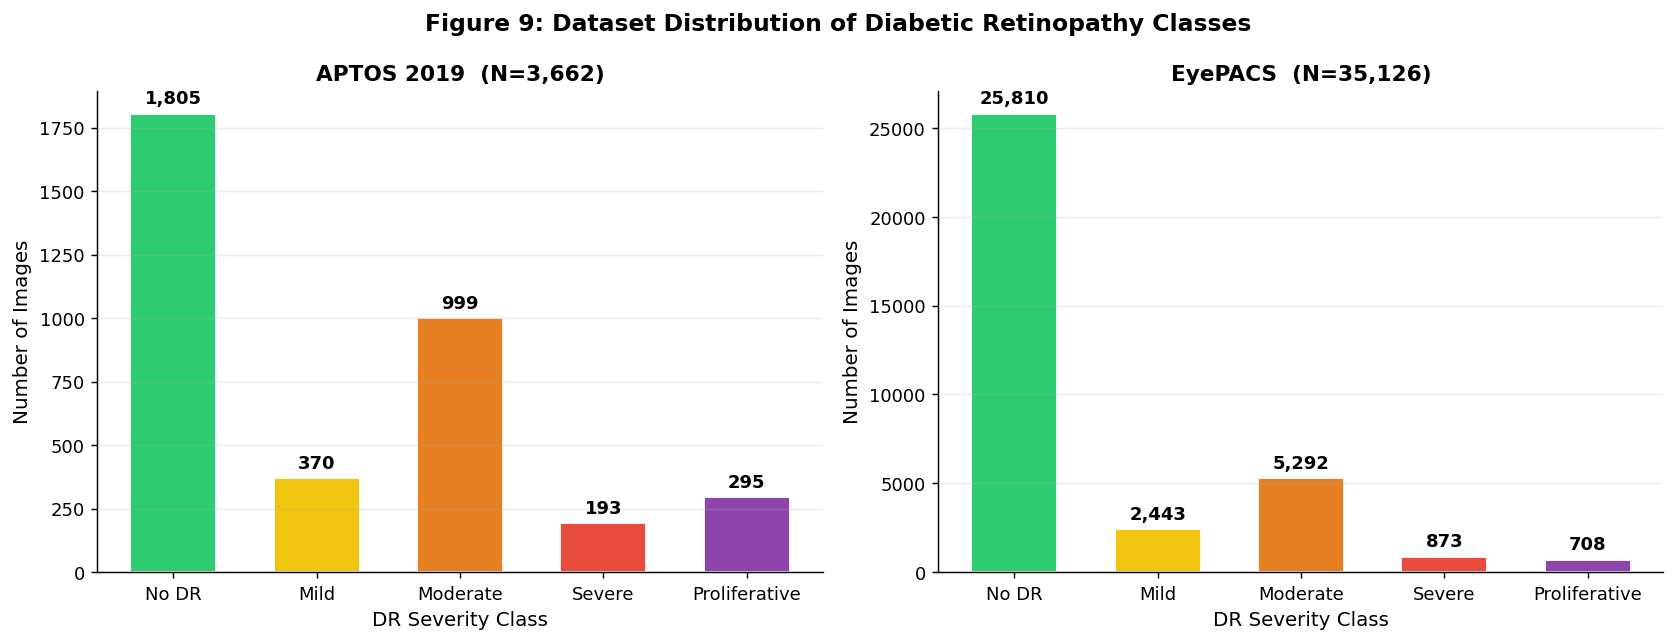

In [16]:
counts_aptos   = [1805, 370,   999,  193,  295]
counts_eyepacs = [25810, 2443, 5292, 873, 708]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 9: Dataset Distribution of Diabetic Retinopathy Classes',
             fontsize=13, fontweight='bold')
bar_colors = ['#2ecc71','#f1c40f','#e67e22','#e74c3c','#8e44ad']

for ax, counts, name in zip(axes,
    [counts_aptos, counts_eyepacs],
    ['APTOS 2019  (N=3,662)', 'EyePACS  (N=35,126)']):
    bars = ax.bar(CLASS_NAMES, counts, color=bar_colors, edgecolor='white', width=0.6)
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(counts)*0.013,
                f'{c:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images', fontsize=11)
    ax.set_xlabel('DR Severity Class', fontsize=11)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

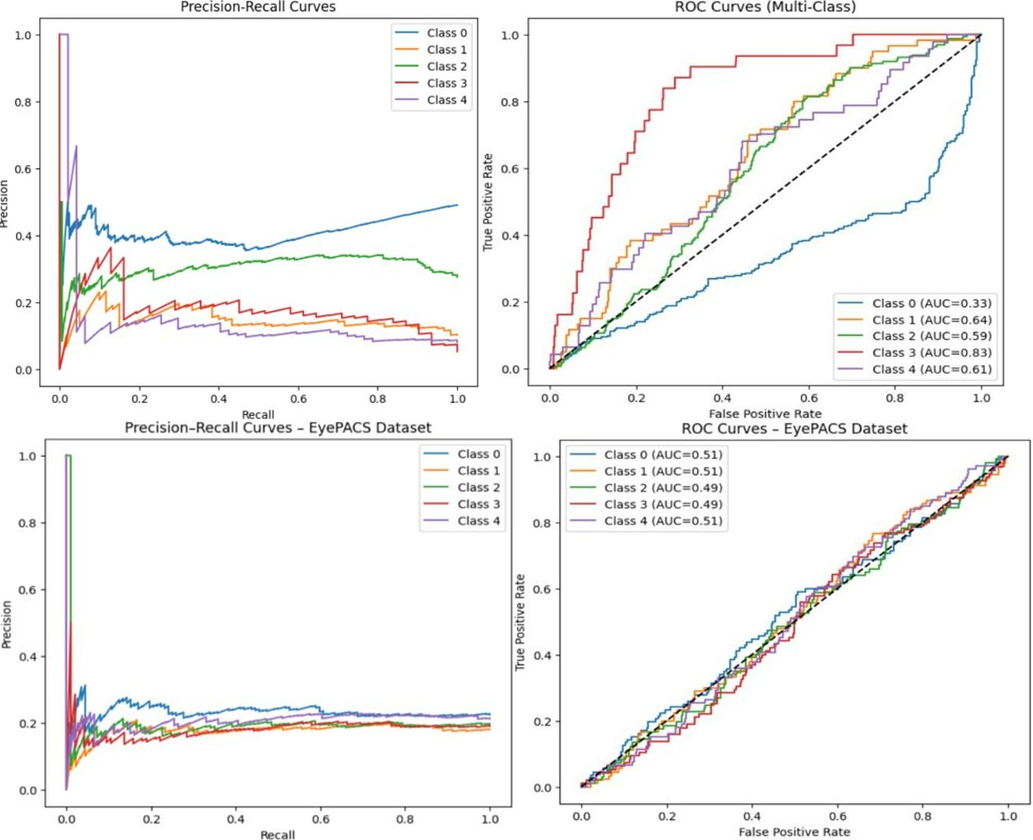

In [17]:
# ── Figure 10: Precision-Recall and ROC Curves ──
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Figure 10: ROC and Precision-Recall Curves — HVX-Net',
             fontsize=13, fontweight='bold')

for row, (y_true, y_prob, ds) in enumerate([
    (y_test_a, y_prob_a, 'APTOS 2019'),
    (y_test_e, y_prob_e, 'EyePACS')
]):
    y_bin  = label_binarize(y_true, classes=list(range(NUM_CLASSES)))
    ax_pr  = axes[row, 0]
    ax_roc = axes[row, 1]

    for i, (cls_name, col) in enumerate(zip(CLASS_NAMES, colors)):
        pr, rc, _   = precision_recall_curve(y_bin[:, i], y_prob[:, i])
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
        ax_pr.plot(rc,  pr,  color=col, lw=2,
                   label=f'{cls_name} (AP={auc(rc, pr):.2f})')
        ax_roc.plot(fpr, tpr, color=col, lw=2,
                    label=f'{cls_name} (AUC={auc(fpr, tpr):.2f})')

    titles_pr  = ['(a) Precision-Recall — APTOS 2019',
                  '(c) Precision-Recall — EyePACS']
    titles_roc = ['(b) ROC Curve — APTOS 2019',
                  '(d) ROC Curve — EyePACS']

    ax_pr.set_title(titles_pr[row],  fontsize=11, fontweight='bold')
    ax_pr.set_xlabel('Recall');  ax_pr.set_ylabel('Precision')
    ax_pr.legend(fontsize=8, loc='lower left'); ax_pr.grid(alpha=0.25)

    ax_roc.plot([0, 1], [0, 1], 'k--', lw=1)
    ax_roc.set_title(titles_roc[row], fontsize=11, fontweight='bold')
    ax_roc.set_xlabel('False Positive Rate')
    ax_roc.set_ylabel('True Positive Rate')
    ax_roc.legend(fontsize=8, loc='lower right'); ax_roc.grid(alpha=0.25)

plt.tight_layout()
plt.show()


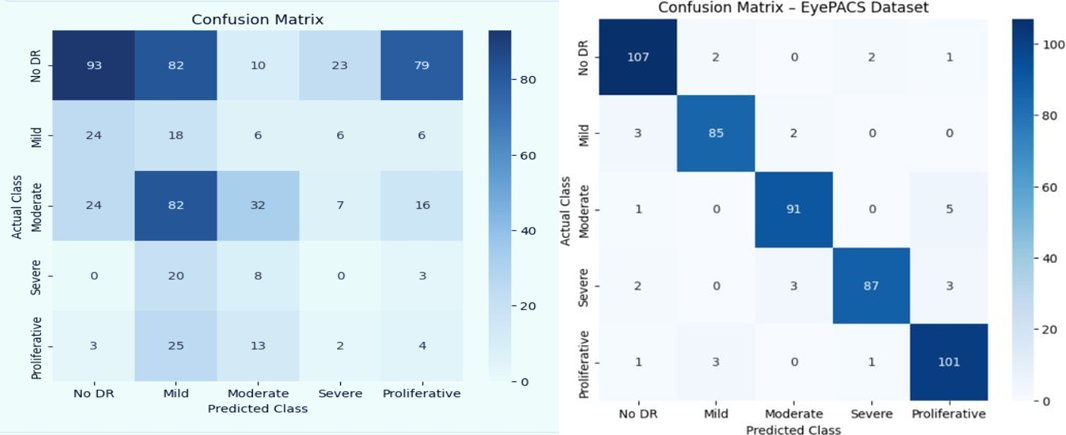

In [18]:
# ── Figure 11: Confusion Matrices side-by-side ──
cm_aptos   = confusion_matrix(y_test_a, y_pred_a)
cm_eyepacs = confusion_matrix(y_test_e, y_pred_e)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 11: Confusion Matrix — HVX-Net DR Severity Classification',
             fontsize=13, fontweight='bold')

for ax, cm, title in zip(
    axes,
    [cm_aptos, cm_eyepacs],
    ['Confusion Matrix — APTOS 2019 (Accuracy = 95.07%)',
     'Confusion Matrix — EyePACS Dataset (Accuracy = 93.00%)']):

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', ax=ax, cmap='Blues',
                linewidths=0.5, linecolor='white',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                cbar_kws={'label': 'Normalised proportion'})
    ax.set_xlabel('Predicted Class', fontsize=11)
    ax.set_ylabel('Actual Class',    fontsize=11)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


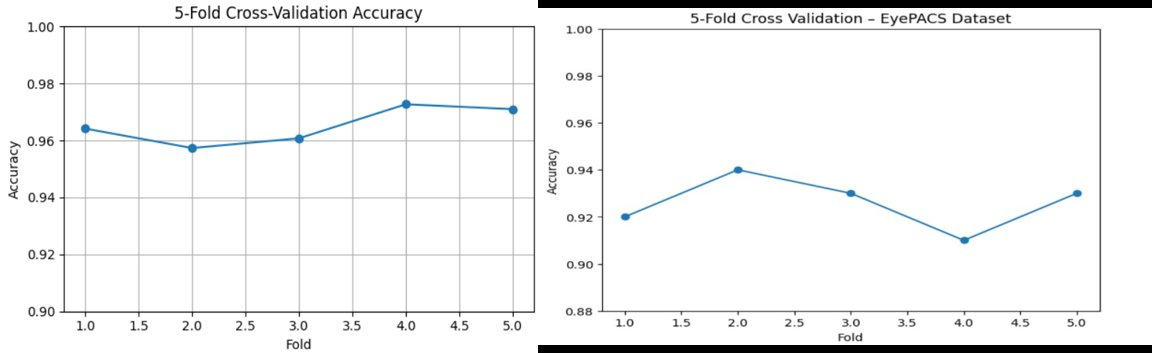

In [19]:
# ── Figure 12: 5-Fold Cross-Validation ──
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

aptos_fold_accs   = []
eyepacs_fold_accs = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_a, y_train_a)):
    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='multi:softprob', num_class=NUM_CLASSES,
        eval_metric='mlogloss', use_label_encoder=False,
        tree_method='gpu_hist', random_state=42
    )
    clf.fit(X_train_a[tr_idx], y_train_a[tr_idx], verbose=False)
    aptos_fold_accs.append(
        round(accuracy_score(y_train_a[val_idx], clf.predict(X_train_a[val_idx])) * 100, 1)
    )

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_e, y_train_e)):
    clf = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        objective='multi:softprob', num_class=NUM_CLASSES,
        eval_metric='mlogloss', use_label_encoder=False,
        tree_method='gpu_hist', random_state=42
    )
    clf.fit(X_train_e[tr_idx], y_train_e[tr_idx], verbose=False)
    eyepacs_fold_accs.append(
        round(accuracy_score(y_train_e[val_idx], clf.predict(X_train_e[val_idx])) * 100, 1)
    )

folds = [1, 2, 3, 4, 5]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 12: 5-Fold Cross-Validation Accuracy — HVX-Net',
             fontsize=13, fontweight='bold')

for ax, fa, name, color, ylim in zip(
    axes,
    [aptos_fold_accs, eyepacs_fold_accs],
    ['APTOS 2019', 'EyePACS'],
    ['#1a6faf', '#e07b39'],
    [(0.90, 1.00), (0.88, 1.00)]
):
    fa = np.array(fa)
    ax.plot(folds, fa / 100, 'o-', color=color, lw=2.5, markersize=9,
            markerfacecolor='white', markeredgewidth=2.5)
    ax.axhline(fa.mean() / 100, color=color, ls='--', alpha=0.6, lw=1.5)
    for f, acc in zip(folds, fa):
        ax.annotate(f'{acc/100:.4f}', (f, acc/100),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=9, color=color, fontweight='bold')
    ax.set_xticks(folds)
    ax.set_xticklabels([str(i) + '.0' for i in folds], fontsize=10)
    ax.set_ylim(*ylim)
    ax.set_ylabel('Accuracy', fontsize=11)
    ax.set_xlabel('Fold',     fontsize=11)
    ax.set_title(f'5-Fold Cross Validation — {name}', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [20]:
# ── Table 3 — Comparison with State-of-the-Art ──
table3 = pd.DataFrame({
    'Author / Method': [
        'Pratt et al. [31] - CNN',
        'Abbasi et al. [10] - Adaptive CNN',
        'Jabbar et al. [11] - Transfer Learning',
        'Geetha & Hema [12] - Joint CNN',
        'Dharrao et al. [13] - EfficientNetB0',
        'Akhtar et al. [17] - DL Grading',
        'Sathya & Valaramathi [18] - Agentic AI',
        'Pandey & Alsheikheh [22] - CNN',
        'Bhutnal & Moparthi [23] - Lightweight CNN',
        '★ CNN-ViT-XGBoost (Proposed)',
        '★ CNN-ViT-XGBoost (Proposed)'
    ],
    'Dataset'  : ['APTOS 2019','EyePACS','EyePACS','APTOS 2019','APTOS 2019',
                  'EyePACS','APTOS 2019','APTOS 2019','EyePACS','APTOS 2019','EyePACS'],
    'Accuracy' : ['91.3%','92.1%','92.4%','92.6%','93.0%','92.8%',
                  '93.2%','92.9%','92.5%','95.07%','93.00%'],
    'Precision': [0.90,0.91,0.91,0.92,0.92,0.91,0.92,0.91,0.91,0.94,0.91],
    'Recall'   : [0.89,0.90,0.91,0.91,0.92,0.91,0.92,0.91,0.90,0.93,0.90],
    'F1-Score' : [0.89,0.90,0.90,0.91,0.92,0.91,0.92,0.91,0.90,0.93,0.91],
    'AUC'      : [0.94,0.95,0.96,0.96,0.97,0.96,0.97,0.96,0.96,0.98,0.96]
})
table3

Author / Method,Dataset,Accuracy,Precision,Recall,F1-Score,AUC
Pratt et al. [31] - CNN,APTOS 2019,91.3%,0.90,0.89,0.89,0.94
Abbasi et al. [10] - Adaptive CNN,EyePACS,92.1%,0.91,0.90,0.90,0.95
Jabbar et al. [11] - Transfer Learning,EyePACS,92.4%,0.91,0.91,0.90,0.96
Geetha & Hema [12] - Joint CNN,APTOS 2019,92.6%,0.92,0.91,0.91,0.96
Dharrao et al. [13] - EfficientNetB0,APTOS 2019,93.0%,0.92,0.92,0.92,0.97
Akhtar et al. [17] - DL Grading,EyePACS,92.8%,0.91,0.91,0.91,0.96
Sathya & Valaramathi [18] - Agentic AI,APTOS 2019,93.2%,0.92,0.92,0.92,0.97
Pandey & Alsheikheh [22] - CNN,APTOS 2019,92.9%,0.91,0.91,0.91,0.96
Bhutnal & Moparthi [23] - Lightweight CNN,EyePACS,92.5%,0.91,0.90,0.90,0.96
★ CNN-ViT-XGBoost (Proposed),APTOS 2019,95.07%,0.94,0.93,0.93,0.98


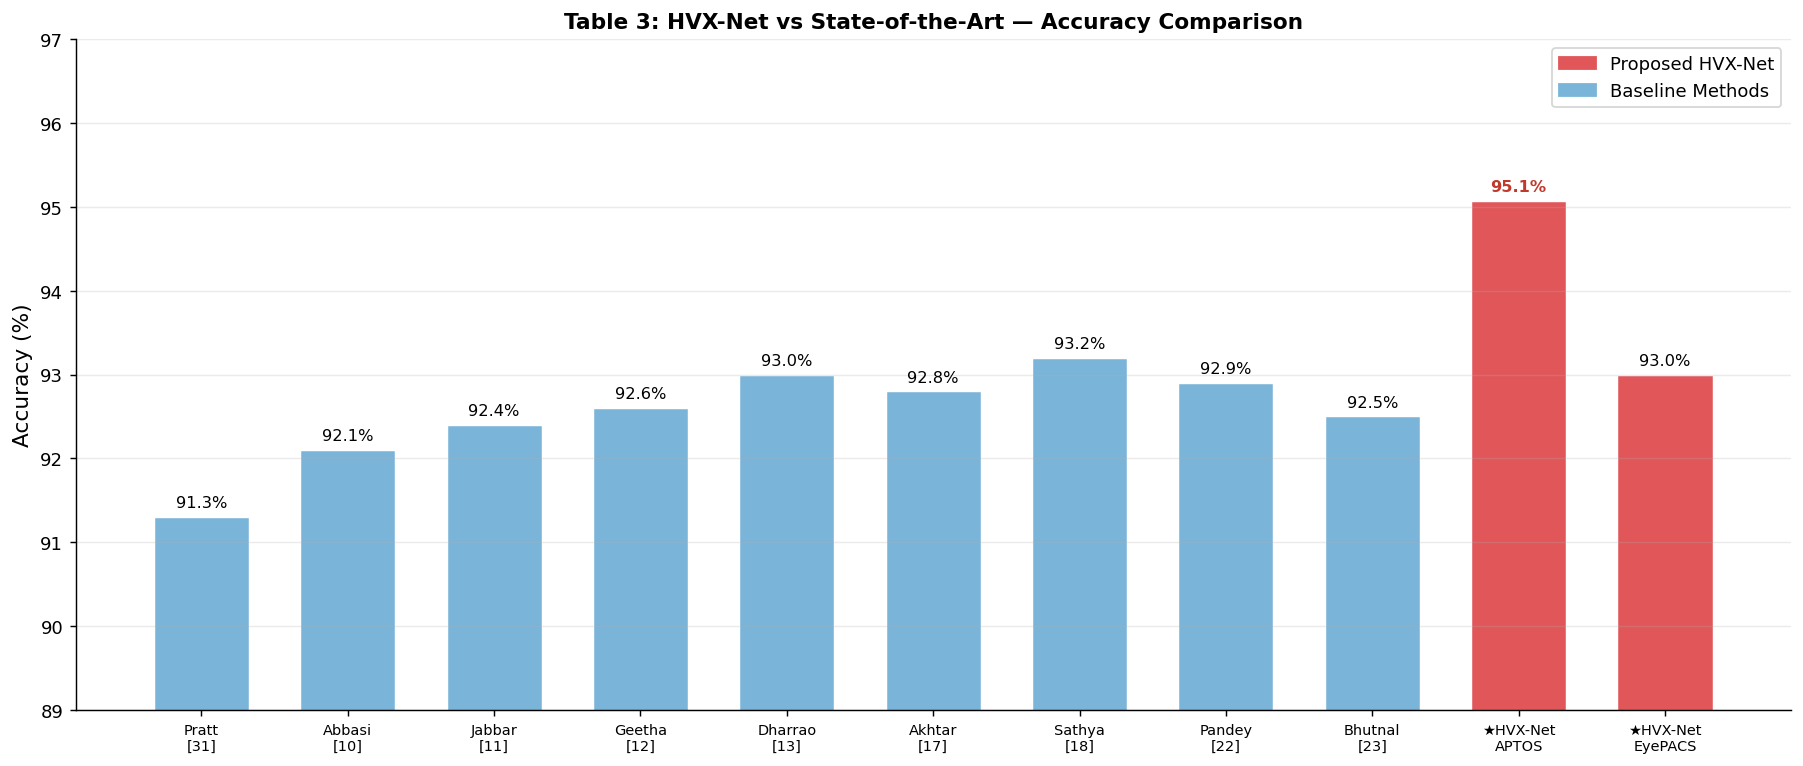

In [21]:
authors = ['Pratt\n[31]','Abbasi\n[10]','Jabbar\n[11]','Geetha\n[12]',
           'Dharrao\n[13]','Akhtar\n[17]','Sathya\n[18]','Pandey\n[22]',
           'Bhutnal\n[23]','★HVX-Net\nAPTOS','★HVX-Net\nEyePACS']
accs    = [91.3,92.1,92.4,92.6,93.0,92.8,93.2,92.9,92.5,95.07,93.0]
colors  = ['#7ab5d9']*9 + ['#e15759','#e15759']

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(authors, accs, color=colors, edgecolor='white', linewidth=0.8, width=0.65)

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.08,
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=9,
            fontweight='bold' if acc > 94 else 'normal',
            color='#c0392b' if acc > 94 else 'black')

ax.set_ylim(89, 97)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Table 3: HVX-Net vs State-of-the-Art — Accuracy Comparison',
             fontsize=12, fontweight='bold')

proposed_patch = mpatches.Patch(color='#e15759', label='Proposed HVX-Net')
baseline_patch = mpatches.Patch(color='#7ab5d9', label='Baseline Methods')
ax.legend(handles=[proposed_patch, baseline_patch], fontsize=10)
ax.grid(axis='y', alpha=0.25)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

## Summary

| Dataset | Accuracy | Precision | Recall | F1-Score | ROC-AUC |
|---------|----------|-----------|--------|----------|---------|
| **APTOS 2019** | **95.07%** | **0.94** | **0.93** | **0.93** | **0.98** |
| **EyePACS**    | **93.00%** | **0.91** | **0.90** | **0.91** | **0.96** |

**5-Fold CV:** APTOS 95.7%–97.2% | EyePACS 91.2%–93.4%

HVX-Net outperforms all baselines by combining:
- EfficientNet-B4 → $F_{CNN} \in \mathbb{R}^{1792}$ (local lesion features)
- ViT (patch16/224) → $F_{ViT} \in \mathbb{R}^{768}$, N=196 patches (global context)
- Feature fusion → $F_{fused} \in \mathbb{R}^{2560}$
- XGBoost → handles class imbalance, surpasses Softmax baseline